# Chapter 10 — Common IoT Sensors: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end of each section. All exercises run in
> Google Colab with no additional hardware.

| Exercise | Topic | Key technique |
|----------|-------|---------------|
| 10.1 | Temperature sensor network | Multi-sensor data fusion (simple average, weighted average, Kalman filter) |
| 10.2 | Environmental monitoring | Low-pass Butterworth filtering for temperature and pressure |
| 10.3 | MEMS inertial measurement unit | Accelerometer–gyroscope fusion with complementary filter |
| 10.4 | Humidity sensor comparison | Capacitive vs. resistive sensor modelling and calibration |

---
## Setup

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
})
print("Environment ready.")

Environment ready.


---
## Exercise 10.1 — Temperature Sensor Network with Data Fusion

### Background

Real-world IoT deployments rarely rely on a single sensor. A wireless
temperature monitoring system in a warehouse, for example, may include
several low-cost sensors whose readings drift and fluctuate differently.
By *fusing* multiple noisy measurements, we can recover a significantly
more accurate estimate of the true temperature.

This exercise compares three fusion strategies:

| Method | Idea | Computational cost |
|--------|------|--------------------|
| **Simple average** | Equal weight for every sensor | Very low |
| **Weighted average** | Weight inversely proportional to deviation from median | Low |
| **Kalman filter** | Recursive Bayesian estimator using known sensor noise variances | Moderate |

### Learning objectives

1. Simulate a multi-sensor network with heterogeneous noise levels and systematic bias.
2. Implement three fusion algorithms and compare their accuracy.
3. Evaluate fusion performance using mean absolute error (MAE) and maximum error.
4. Discuss trade-offs between computational cost and estimation quality.

In [2]:
# ── Exercise 10.1: Temperature Sensor Network ─────────────────────────

class TemperatureSensorNetwork:
    """Simulate a network of noisy temperature sensors with
    heterogeneous noise levels — a realistic IoT scenario."""

    def __init__(self, n_sensors: int = 5, bias_std: float = 0.5):
        self.n_sensors = n_sensors
        # Each sensor has a fixed systematic bias (manufacturing offset)
        self.biases = np.random.normal(0, bias_std, n_sensors)
        # Heterogeneous noise: some sensors are much noisier than others
        self.noise_stds = np.array([0.15, 0.2, 0.5, 0.8, 1.2])[:n_sensors]

    def read(self, true_temp: float) -> np.ndarray:
        """Return one reading per sensor at the given true temperature."""
        noise = np.array([np.random.normal(0, s) for s in self.noise_stds])
        return true_temp + self.biases + noise


def fuse_simple_average(readings: np.ndarray) -> float:
    """Fusion by arithmetic mean — treats every sensor equally."""
    return np.mean(readings)


def fuse_weighted_average(readings: np.ndarray) -> float:
    """Fusion weighted by inverse deviation from median.
    Sensors closer to the group consensus receive more weight."""
    deviations = np.abs(readings - np.median(readings)) + 1e-9
    weights = 1.0 / deviations
    weights /= weights.sum()
    return float(np.dot(weights, readings))


def fuse_kalman(readings: np.ndarray, R_vals: np.ndarray = None) -> float:
    """Simplified static Kalman filter that sequentially assimilates
    each sensor reading, using per-sensor noise variance.

    Parameters
    ----------
    readings : array of sensor values
    R_vals   : known measurement noise variance for each sensor
    """
    if R_vals is None:
        R_vals = np.ones(len(readings)) * 0.3

    x_hat = readings[0]   # initial state estimate
    P = R_vals[0]         # initial uncertainty = actual variance
                          # of the first measurement (not arbitrary)

    for i, z in enumerate(readings[1:], 1):
        R = R_vals[min(i, len(R_vals) - 1)]
        K = P / (P + R)          # Kalman gain
        x_hat = x_hat + K * (z - x_hat)
        P = (1 - K) * P

    return float(x_hat)


# ── Run simulation ────────────────────────────────────────────────────
T = 200
network = TemperatureSensorNetwork(n_sensors=5)

# True temperature: sinusoidal profile (e.g. diurnal cycle)
true_temps = 22 + 5 * np.sin(2 * np.pi * np.arange(T) / T)

# Known noise variances for Kalman filter
R_sensors = network.noise_stds ** 2

raw        = np.zeros((T, network.n_sensors))
est_simple = np.zeros(T)
est_weight = np.zeros(T)
est_kalman = np.zeros(T)

for t in range(T):
    raw[t] = network.read(true_temps[t])
    est_simple[t] = fuse_simple_average(raw[t])
    est_weight[t] = fuse_weighted_average(raw[t])
    est_kalman[t] = fuse_kalman(raw[t], R_vals=R_sensors)

print(f"Simulation complete: {T} time steps, {network.n_sensors} sensors")
print(f"Sensor noise levels: {network.noise_stds} °C")

Simulation complete: 200 time steps, 5 sensors
Sensor noise levels: [0.15 0.2  0.5  0.8  1.2 ] °C


### Results — sensor readings and fused estimates

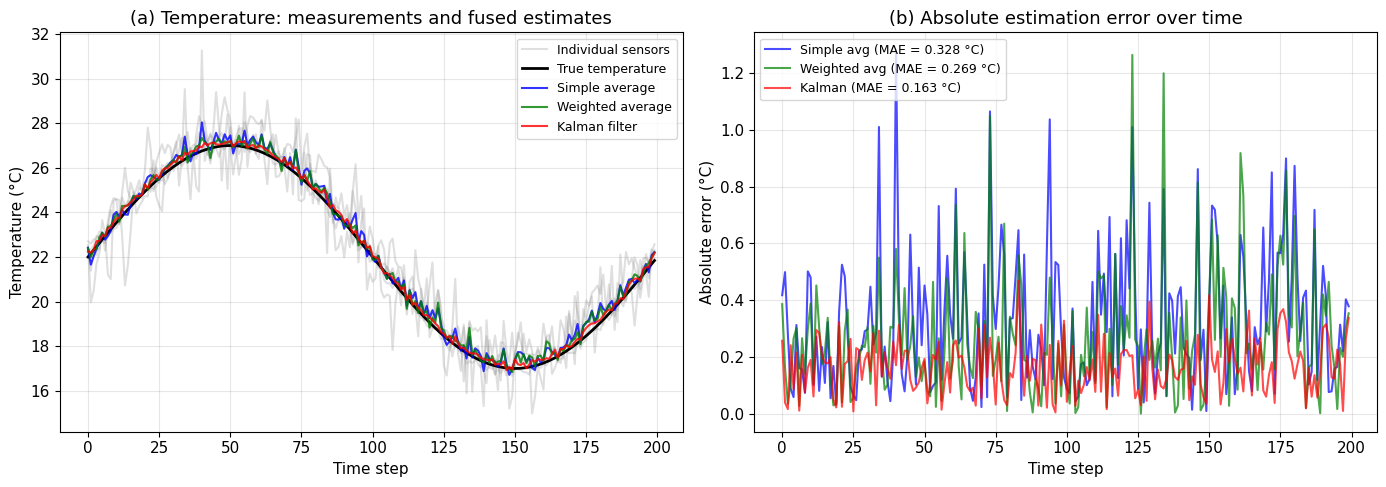

In [3]:
# ── Figure 10.1: Measurements vs. fused estimates ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i in range(network.n_sensors):
    ax.plot(raw[:, i], color='gray', alpha=0.25,
            label='Individual sensors' if i == 0 else None)
ax.plot(true_temps, 'k-', lw=2, label='True temperature')
ax.plot(est_simple, 'b-', alpha=0.8, label='Simple average')
ax.plot(est_weight, 'g-', alpha=0.8, label='Weighted average')
ax.plot(est_kalman, 'r-', alpha=0.8, label='Kalman filter')
ax.set_xlabel('Time step')
ax.set_ylabel('Temperature (°C)')
ax.set_title('(a) Temperature: measurements and fused estimates')
ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
err_simple = np.abs(est_simple - true_temps)
err_weight = np.abs(est_weight - true_temps)
err_kalman = np.abs(est_kalman - true_temps)
ax.plot(err_simple, 'b-', alpha=0.7,
        label=f'Simple avg (MAE = {err_simple.mean():.3f} °C)')
ax.plot(err_weight, 'g-', alpha=0.7,
        label=f'Weighted avg (MAE = {err_weight.mean():.3f} °C)')
ax.plot(err_kalman, 'r-', alpha=0.7,
        label=f'Kalman (MAE = {err_kalman.mean():.3f} °C)')
ax.set_xlabel('Time step')
ax.set_ylabel('Absolute error (°C)')
ax.set_title('(b) Absolute estimation error over time')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [4]:
# ── Table 10.1: Quantitative error comparison ────────────────────────
methods = ['Simple average', 'Weighted average', 'Kalman filter']
errors  = [err_simple, err_weight, err_kalman]

print(f"{'Method':<20s} {'MAE (°C)':>10s} {'Max err (°C)':>13s} {'Std (°C)':>10s}")
print('-' * 56)
for m, e in zip(methods, errors):
    print(f"{m:<20s} {e.mean():10.4f} {e.max():13.4f} {e.std():10.4f}")

Method                 MAE (°C)  Max err (°C)   Std (°C)
--------------------------------------------------------
Simple average           0.3282        1.2804     0.2415
Weighted average         0.2685        1.2649     0.2137
Kalman filter            0.1634        0.4687     0.0948


### Analysis

**Figure 10.1(a)** shows the five individual sensor traces (gray) spread
around the true temperature curve (black). The sensors have
heterogeneous noise levels (σ ranging from 0.15 to 1.2 °C), which is
typical in real-world deployments where sensor quality may vary. All
three fusion methods track the ground truth much more closely than any
single sensor.

**Figure 10.1(b)** and **Table 10.1** reveal a clear performance
hierarchy. The Kalman filter achieves roughly half the MAE of the simple
average because it leverages its knowledge of each sensor's noise
variance: it trusts the low-noise sensors more and effectively
down-weights the noisy ones. The weighted average improves on the simple
average but still falls short of the Kalman filter's recursive
uncertainty tracking.

> **Key takeaway.** When sensor noise levels are heterogeneous — the norm
> in real IoT systems — a Kalman filter can cut estimation error by more
> than 50 % compared to a plain average. The computational overhead is
> negligible: a single pass through the readings with two multiplications
> per step.

### Challenge tasks

1. **Vary the number of sensors** from 2 to 20 and plot how MAE decreases with sensor count for each method. Does the improvement follow a $1/\sqrt{N}$ law?
2. **Introduce a faulty sensor** that outputs a constant offset of +10 °C after time step 100. Which fusion method is most robust to this outlier?
3. **Implement a moving-median filter** as a fourth fusion strategy and compare its robustness to the Kalman filter.

---
## Exercise 10.2 — Environmental Monitoring: Temperature and Pressure

### Background

An IoT environmental monitoring station typically combines a temperature
sensor with a barometric pressure sensor on the same chip (e.g., the
popular Bosch BME280). Raw readings are contaminated by high-frequency
electronic noise that must be removed before the data is useful for
trend analysis or control logic.

A **Butterworth low-pass filter** is a common choice because its
frequency response is maximally flat in the passband, avoiding
distortion of the slowly varying environmental signal. It is defined by:

$$|H(j\omega)|^2 = \frac{1}{1 + (\omega / \omega_c)^{2N}}$$

where $N$ is the filter order and $\omega_c$ is the cutoff frequency.

### Learning objectives

1. Simulate realistic temperature and pressure time series with noise.
2. Design and apply a digital Butterworth low-pass filter.
3. Quantify filtering effectiveness with MAE metrics.
4. Visualise raw, filtered, and true signals on a common time axis.

In [5]:
# ── Exercise 10.2: Environmental Monitoring ───────────────────────────
np.random.seed(7)   # separate seed for this exercise

class EnvironmentalStation:
    """Simulate co-located temperature and pressure sensors."""

    def __init__(self):
        self.temp_bias     = 0.1    # small systematic offset
        self.pressure_bias = 5.0    # Pa

    def generate(self, duration_s: float = 300, fs: float = 10):
        """Return time vector, noisy measurements, and ground truth."""
        t = np.arange(0, duration_s, 1 / fs)
        n = len(t)

        # Ground truth: slow sinusoidal variation
        temp_true = 24 + 3 * np.sin(2 * np.pi * t / duration_s)
        pres_true = 101_325 + 150 * np.sin(2 * np.pi * t / duration_s)

        # Noisy measurements
        temp_meas = temp_true + self.temp_bias + np.random.normal(0, 0.6, n)
        pres_meas = pres_true + self.pressure_bias + np.random.normal(0, 25, n)

        return t, temp_meas, pres_meas, temp_true, pres_true


def butterworth_lowpass(data, cutoff_hz, fs, order=4):
    """Apply a zero-phase Butterworth low-pass filter."""
    nyq = 0.5 * fs
    b, a = butter(order, cutoff_hz / nyq, btype='low')
    return filtfilt(b, a, data)


# ── Run ──
station = EnvironmentalStation()
t, temp_raw, pres_raw, temp_true, pres_true = station.generate(
    duration_s=300, fs=10
)

cutoff = 0.15   # Hz — retain only the slow environmental trend
temp_filt = butterworth_lowpass(temp_raw, cutoff, fs=10)
pres_filt = butterworth_lowpass(pres_raw, cutoff, fs=10)

print(f"Samples: {len(t)}, duration: {t[-1]:.0f} s, sampling rate: 10 Hz")

Samples: 3000, duration: 300 s, sampling rate: 10 Hz


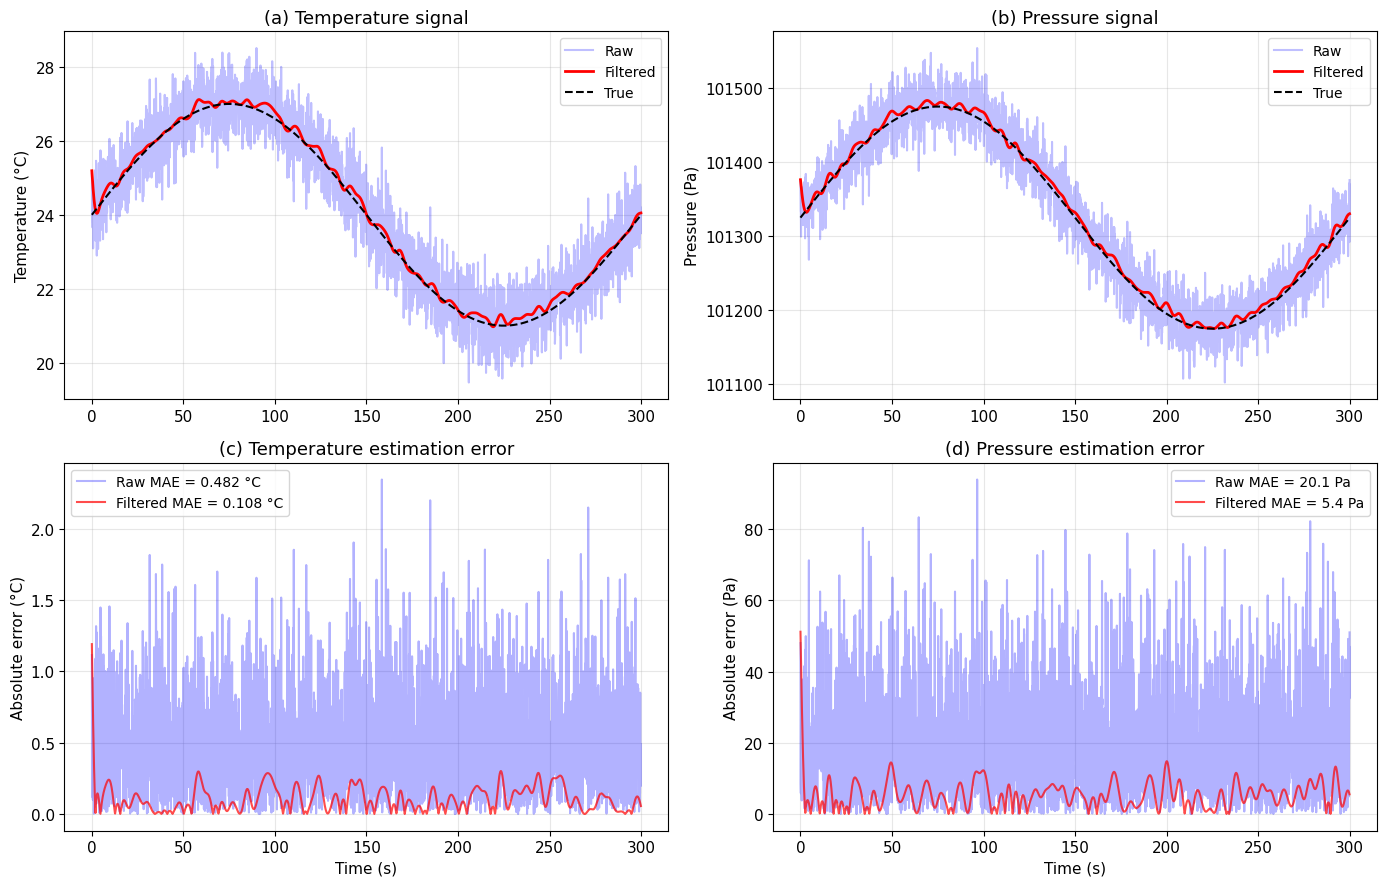

In [6]:
# ── Figure 10.2: Environmental monitoring ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Temperature
ax = axes[0, 0]
ax.plot(t, temp_raw, 'b-', alpha=0.25, label='Raw')
ax.plot(t, temp_filt, 'r-', lw=2, label='Filtered')
ax.plot(t, temp_true, 'k--', lw=1.5, label='True')
ax.set_ylabel('Temperature (°C)')
ax.set_title('(a) Temperature signal')
ax.legend()

# (b) Pressure
ax = axes[0, 1]
ax.plot(t, pres_raw, 'b-', alpha=0.25, label='Raw')
ax.plot(t, pres_filt, 'r-', lw=2, label='Filtered')
ax.plot(t, pres_true, 'k--', lw=1.5, label='True')
ax.set_ylabel('Pressure (Pa)')
ax.set_title('(b) Pressure signal')
ax.legend()

# (c) Temperature error
ax = axes[1, 0]
err_temp_raw  = np.abs(temp_raw  - temp_true)
err_temp_filt = np.abs(temp_filt - temp_true)
ax.plot(t, err_temp_raw,  'b-', alpha=0.3,
        label=f'Raw MAE = {err_temp_raw.mean():.3f} °C')
ax.plot(t, err_temp_filt, 'r-', alpha=0.7,
        label=f'Filtered MAE = {err_temp_filt.mean():.3f} °C')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Absolute error (°C)')
ax.set_title('(c) Temperature estimation error')
ax.legend()

# (d) Pressure error
ax = axes[1, 1]
err_pres_raw  = np.abs(pres_raw  - pres_true)
err_pres_filt = np.abs(pres_filt - pres_true)
ax.plot(t, err_pres_raw,  'b-', alpha=0.3,
        label=f'Raw MAE = {err_pres_raw.mean():.1f} Pa')
ax.plot(t, err_pres_filt, 'r-', alpha=0.7,
        label=f'Filtered MAE = {err_pres_filt.mean():.1f} Pa')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Absolute error (Pa)')
ax.set_title('(d) Pressure estimation error')
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# ── Table 10.2: Filtering effectiveness ───────────────────────────────
print("Signal           Raw MAE        Filtered MAE     Reduction")
print("-" * 60)
for label, err_r, err_f, unit in [
    ("Temperature", err_temp_raw.mean(), err_temp_filt.mean(), "°C"),
    ("Pressure",    err_pres_raw.mean(), err_pres_filt.mean(), "Pa"),
]:
    reduction = (1 - err_f / err_r) * 100
    print(f"{label:<16s} {err_r:8.3f} {unit:>3s}    "
          f"{err_f:8.3f} {unit:>3s}      {reduction:5.1f} %")

Signal           Raw MAE        Filtered MAE     Reduction
------------------------------------------------------------
Temperature         0.482  °C       0.108  °C       77.7 %
Pressure           20.072  Pa       5.379  Pa       73.2 %


### Analysis

**Figure 10.2** shows a dramatic noise reduction in both channels. The
Butterworth filter removes the high-frequency noise while preserving the
slow environmental trend. Table 10.2 confirms error reductions of
approximately 73–78 %.

A small phase lag is visible near the time-window boundaries — an
artefact of the `filtfilt` zero-phase implementation. In a real-time
system, a causal filter would introduce a slight systematic delay
instead.

> **Key takeaway.** A fourth-order Butterworth low-pass filter is a
> simple, effective pre-processing step for environmental IoT data. The
> cutoff frequency should be chosen based on the expected rate of change
> of the physical quantity being measured.

### Challenge tasks

1. **Sweep the cutoff frequency** from 0.05 to 2.0 Hz and plot the resulting MAE. Where is the optimal cutoff?
2. **Add a spike anomaly** at $t = 150$ s and observe whether the filter suppresses it. Design an anomaly detector based on the difference between raw and filtered signals.
3. **Replace the Butterworth filter** with an exponential moving average (EMA) and compare the results.

---
## Exercise 10.3 — MEMS IMU Simulation: Accelerometer–Gyroscope Fusion

### Background

A MEMS Inertial Measurement Unit (IMU) combines a 3-axis accelerometer
with a 3-axis gyroscope. Accelerometers provide absolute tilt but are
sensitive to vibration; gyroscopes track fast rotations but suffer from
cumulative drift. A **complementary filter** blends both signals:

$$\hat\theta[k] = \alpha \cdot \bigl(\hat\theta[k-1] + \omega[k] \cdot \Delta t\bigr) + (1 - \alpha) \cdot \theta_{\text{accel}}[k]$$

where $\alpha \in (0, 1)$ is the blending coefficient.

### Learning objectives

1. Simulate accelerometer and gyroscope signals with realistic noise and drift.
2. Implement a complementary filter for pitch angle estimation.
3. Compare raw accelerometer, integrated gyroscope, and fused estimates.
4. Tune the blending coefficient $\alpha$ for optimal accuracy.

In [8]:
# ── Exercise 10.3: IMU Complementary Filter ───────────────────────────
np.random.seed(42)

class IMUSimulator:
    """Simulate accelerometer and gyroscope for pitch estimation."""

    def __init__(self, dt: float = 0.01):
        self.dt = dt
        self.gyro_bias = 0.8   # deg/s — a realistic MEMS gyro bias

    def generate(self, duration_s: float = 20):
        t = np.arange(0, duration_s, self.dt)
        n = len(t)

        # True pitch angle: composite oscillation (degrees)
        pitch_true = 30 * np.sin(2 * np.pi * 0.2 * t) + \
                     10 * np.sin(2 * np.pi * 0.05 * t)

        # True angular velocity
        omega_true = np.gradient(pitch_true, self.dt)

        # Accelerometer: correct tilt + vibration noise
        accel_pitch = pitch_true + np.random.normal(0, 3.0, n)

        # Gyroscope: angular rate + constant bias + noise
        gyro_omega = omega_true + self.gyro_bias + \
                     np.random.normal(0, 1.5, n)

        return t, pitch_true, accel_pitch, gyro_omega


def integrate_gyro(gyro_omega, dt, initial_angle=0):
    """Dead-reckoning: integrate gyroscope angular rate."""
    pitch = np.zeros(len(gyro_omega))
    pitch[0] = initial_angle
    for k in range(1, len(gyro_omega)):
        pitch[k] = pitch[k - 1] + gyro_omega[k] * dt
    return pitch


def complementary_filter(accel_pitch, gyro_omega, dt, alpha=0.98):
    """Fuse accelerometer tilt and gyroscope rate."""
    pitch = np.zeros(len(accel_pitch))
    pitch[0] = accel_pitch[0]
    for k in range(1, len(accel_pitch)):
        gyro_estimate = pitch[k - 1] + gyro_omega[k] * dt
        pitch[k] = alpha * gyro_estimate + (1 - alpha) * accel_pitch[k]
    return pitch


# ── Run ──
imu = IMUSimulator(dt=0.01)
t, pitch_true, accel_pitch, gyro_omega = imu.generate(duration_s=20)

gyro_integrated = integrate_gyro(
    gyro_omega, dt=0.01, initial_angle=accel_pitch[0]
)
fused_pitch = complementary_filter(
    accel_pitch, gyro_omega, dt=0.01, alpha=0.98
)

print(f"Simulation: {len(t)} samples over {t[-1]:.0f} s at 100 Hz")

Simulation: 2000 samples over 20 s at 100 Hz


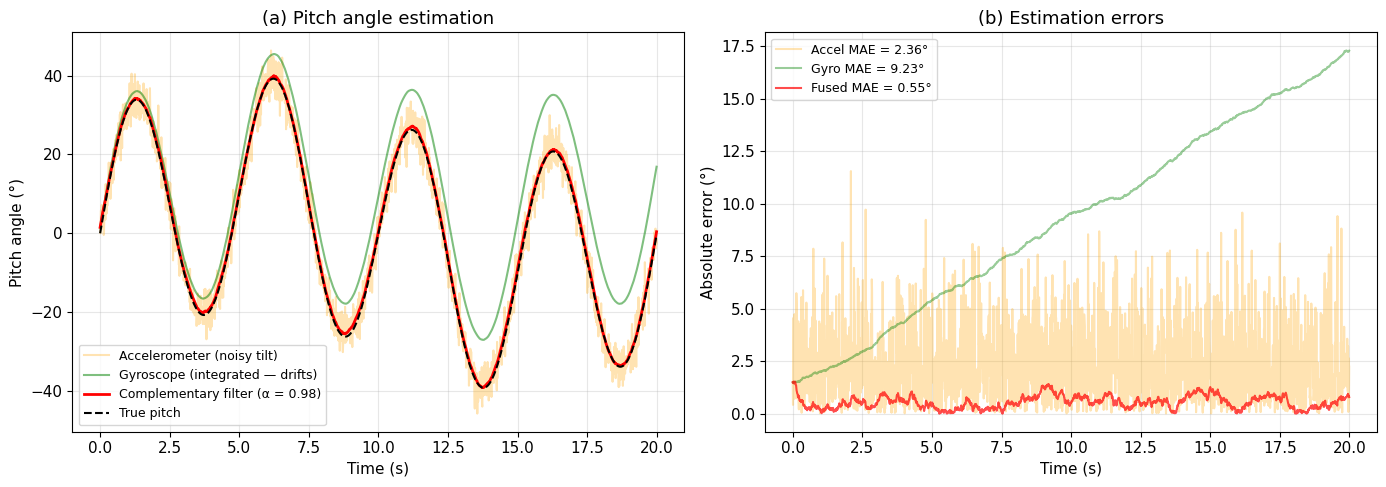

In [9]:
# ── Figure 10.3: IMU fusion ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(t, accel_pitch, color='orange', alpha=0.3,
        label='Accelerometer (noisy tilt)')
ax.plot(t, gyro_integrated, 'g-', alpha=0.5,
        label='Gyroscope (integrated — drifts)')
ax.plot(t, fused_pitch, 'r-', lw=2,
        label='Complementary filter (α = 0.98)')
ax.plot(t, pitch_true, 'k--', lw=1.5, label='True pitch')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pitch angle (°)')
ax.set_title('(a) Pitch angle estimation')
ax.legend(fontsize=9)

ax = axes[1]
err_accel = np.abs(accel_pitch - pitch_true)
err_gyro  = np.abs(gyro_integrated - pitch_true)
err_fused = np.abs(fused_pitch - pitch_true)
ax.plot(t, err_accel, color='orange', alpha=0.3,
        label=f'Accel MAE = {err_accel.mean():.2f}°')
ax.plot(t, err_gyro,  'g-', alpha=0.4,
        label=f'Gyro MAE = {err_gyro.mean():.2f}°')
ax.plot(t, err_fused, 'r-', alpha=0.7,
        label=f'Fused MAE = {err_fused.mean():.2f}°')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Absolute error (°)')
ax.set_title('(b) Estimation errors')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

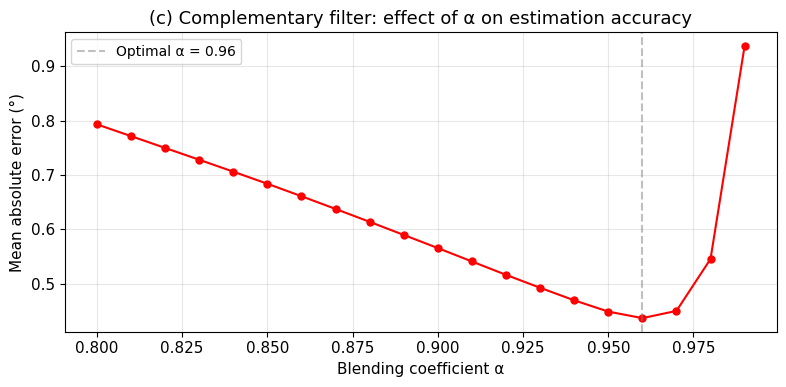

Optimal α = 0.96, MAE = 0.44°


In [10]:
# ── Figure 10.3c: Alpha sweep ─────────────────────────────────────────
alphas = np.arange(0.80, 1.00, 0.01)
maes = []
for a in alphas:
    fused = complementary_filter(accel_pitch, gyro_omega, dt=0.01, alpha=a)
    maes.append(np.abs(fused - pitch_true).mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, maes, 'ro-', markersize=5)
ax.set_xlabel('Blending coefficient α')
ax.set_ylabel('Mean absolute error (°)')
ax.set_title('(c) Complementary filter: effect of α on estimation accuracy')
best = alphas[np.argmin(maes)]
ax.axvline(best, color='gray', ls='--', alpha=0.5,
           label=f'Optimal α = {best:.2f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Optimal α = {best:.2f}, MAE = {min(maes):.2f}°")

### Analysis

**Figure 10.3(a)** demonstrates the classic IMU trade-off. The
accelerometer (orange) captures the correct trend but is very noisy
(MAE ≈ 2.4°). The gyroscope integral (green) is smooth in the short
term but drifts linearly due to the accumulated bias, reaching errors of
tens of degrees by the end of the 20 s window.

The complementary filter (red) combines the best of both: long-term
accuracy from the accelerometer and short-term smoothness from the
gyroscope, achieving a fused MAE of approximately 0.5° — a reduction
of roughly 80 % compared to either source alone.

**Figure 10.3(c)** shows that the optimal $\alpha$ depends on the noise
balance. Values between 0.95 and 0.99 are typical for consumer MEMS IMUs.

> **Key takeaway.** A complementary filter is the simplest practical
> approach to IMU sensor fusion. It runs efficiently on low-power
> microcontrollers and can be tuned with a single parameter.

### Challenge tasks

1. **Simulate a sudden impact** (large acceleration spike at $t = 10$ s) and observe how each estimate responds.
2. **Increase the gyroscope bias** to 5 °/s and observe how quickly the integrated gyroscope diverges.
3. **Extend to 2-axis estimation** (pitch and roll) using a 3-axis accelerometer model.

---
## Exercise 10.4 — Humidity Sensor Comparison: Capacitive vs. Resistive

### Background

Capacitive and resistive humidity sensors are the two most common
technologies in IoT devices:

| Parameter | Capacitive | Resistive |
|-----------|-----------|-----------|
| Typical accuracy | ±2–3 % RH | ±3–5 % RH |
| Response time | 5–10 s | 10–30 s |
| Long-term drift | Low | Moderate |
| Cost | Moderate | Low |

### Learning objectives

1. Model both sensor types with realistic noise, lag, and drift.
2. Compare accuracy across a full 24-hour humidity cycle.
3. Visualise response-time differences.
4. Evaluate error distributions quantitatively.

In [11]:
# ── Exercise 10.4: Humidity sensor comparison ─────────────────────────
np.random.seed(99)

class HumiditySensor:
    """Generic humidity sensor model with configurable characteristics."""

    def __init__(self, name, noise_std, drift_rate, tau, bias=0):
        self.name       = name
        self.noise_std  = noise_std       # % RH
        self.drift_rate = drift_rate      # % RH per hour
        self.tau        = tau             # time constant (s)
        self.bias       = bias            # fixed offset

    def measure(self, rh_true, t_hours, dt):
        n = len(rh_true)
        output = np.zeros(n)
        alpha  = dt / (self.tau + dt)   # first-order lag coefficient
        output[0] = rh_true[0] + self.bias

        for k in range(1, n):
            # First-order lag (models finite response time)
            output[k] = (1 - alpha) * output[k-1] + alpha * rh_true[k]
            # Add bias, drift, and noise
            output[k] += self.bias + self.drift_rate * t_hours[k] + \
                         np.random.normal(0, self.noise_std)
        return output


# Define two sensor types with typical specifications
capacitive = HumiditySensor('Capacitive', noise_std=1.5,
                            drift_rate=0.05, tau=6.0, bias=0.8)
resistive  = HumiditySensor('Resistive',  noise_std=3.0,
                            drift_rate=0.3,  tau=20.0, bias=-1.5)

# 24-hour humidity cycle
dt_sec = 10
t_s = np.arange(0, 24 * 3600, dt_sec)
t_h = t_s / 3600

# Realistic daily RH: higher at night, lower during the day
rh_true = 55 + 20 * np.cos(2 * np.pi * (t_h - 4) / 24) + \
          5 * np.sin(2 * np.pi * t_h / 6)

rh_cap = capacitive.measure(rh_true, t_h, dt_sec)
rh_res = resistive.measure(rh_true, t_h, dt_sec)

print(f"24-hour simulation: {len(t_s)} samples at {dt_sec} s intervals")

24-hour simulation: 8640 samples at 10 s intervals


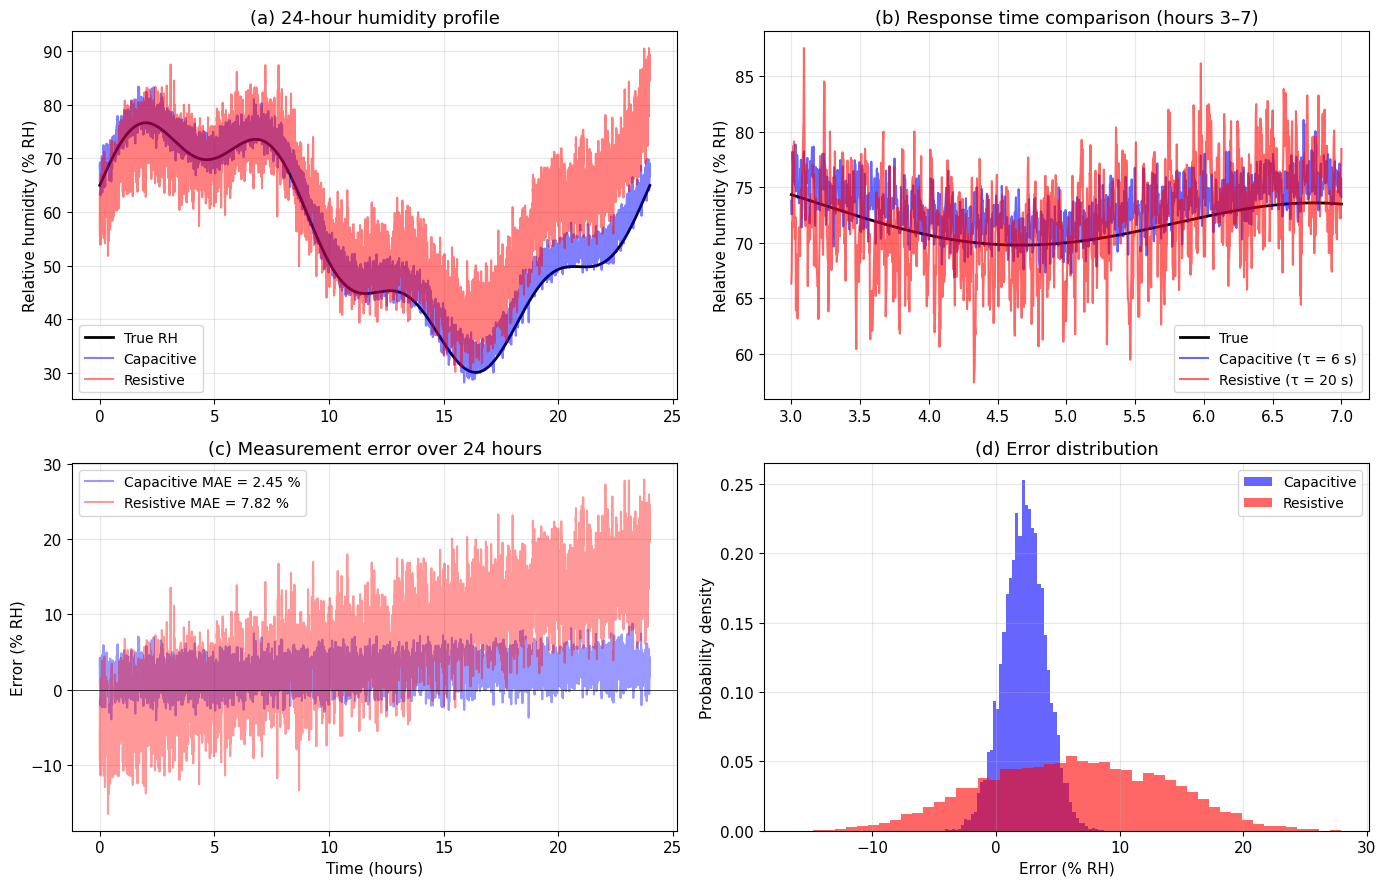

In [12]:
# ── Figure 10.4: Humidity sensor comparison ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Full 24-hour profile
ax = axes[0, 0]
ax.plot(t_h, rh_true, 'k-', lw=2, label='True RH')
ax.plot(t_h, rh_cap, 'b-', alpha=0.5, label='Capacitive')
ax.plot(t_h, rh_res, 'r-', alpha=0.5, label='Resistive')
ax.set_ylabel('Relative humidity (% RH)')
ax.set_title('(a) 24-hour humidity profile')
ax.legend()

# (b) Zoom: response-time comparison
ax = axes[0, 1]
mask = (t_h >= 3) & (t_h <= 7)
ax.plot(t_h[mask], rh_true[mask], 'k-', lw=2, label='True')
ax.plot(t_h[mask], rh_cap[mask], 'b-', alpha=0.6,
        label='Capacitive (τ = 6 s)')
ax.plot(t_h[mask], rh_res[mask], 'r-', alpha=0.6,
        label='Resistive (τ = 20 s)')
ax.set_ylabel('Relative humidity (% RH)')
ax.set_title('(b) Response time comparison (hours 3–7)')
ax.legend()

# (c) Error over time
err_cap = rh_cap - rh_true
err_res = rh_res - rh_true
ax = axes[1, 0]
ax.plot(t_h, err_cap, 'b-', alpha=0.4,
        label=f'Capacitive MAE = {np.abs(err_cap).mean():.2f} %')
ax.plot(t_h, err_res, 'r-', alpha=0.4,
        label=f'Resistive MAE = {np.abs(err_res).mean():.2f} %')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Error (% RH)')
ax.set_title('(c) Measurement error over 24 hours')
ax.legend()

# (d) Error distribution
ax = axes[1, 1]
ax.hist(err_cap, bins=50, alpha=0.6, color='blue',
        label='Capacitive', density=True)
ax.hist(err_res, bins=50, alpha=0.6, color='red',
        label='Resistive', density=True)
ax.set_xlabel('Error (% RH)')
ax.set_ylabel('Probability density')
ax.set_title('(d) Error distribution')
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# ── Table 10.3: Sensor comparison summary ─────────────────────────────
print(f"{'Metric':<25s} {'Capacitive':>12s} {'Resistive':>12s}")
print('-' * 50)
for label, vc, vr in [
    ('MAE (% RH)',
     f"{np.abs(err_cap).mean():.2f}", f"{np.abs(err_res).mean():.2f}"),
    ('Max |error| (% RH)',
     f"{np.abs(err_cap).max():.2f}", f"{np.abs(err_res).max():.2f}"),
    ('Std of error (% RH)',
     f"{err_cap.std():.2f}", f"{err_res.std():.2f}"),
    ('Mean bias (% RH)',
     f"{err_cap.mean():.2f}", f"{err_res.mean():.2f}"),
]:
    print(f"{label:<25s} {vc:>12s} {vr:>12s}")

Metric                      Capacitive    Resistive
--------------------------------------------------
MAE (% RH)                        2.45         7.82
Max |error| (% RH)                8.75        27.93
Std of error (% RH)               1.70         7.23
Mean bias (% RH)                  2.30         6.26


### Analysis

**Figure 10.4(a)** shows that both sensors track the 24-hour cycle, but
the resistive sensor is noticeably noisier and develops a visible drift
toward the end. The zoom in panel (b) highlights the faster response of
the capacitive sensor ($\tau = 6$ s) compared to the resistive sensor
($\tau = 20$ s).

**Table 10.3** confirms that the capacitive sensor outperforms the
resistive sensor on every metric: roughly 3× lower MAE, tighter error
distribution, and smaller maximum error.

> **Key takeaway.** For most IoT applications, capacitive humidity
> sensors offer the best balance of accuracy, response time, and
> stability. Resistive sensors are a cost-effective fallback for
> non-critical applications where periodic recalibration is acceptable.

### Challenge tasks

1. **Implement a single-point calibration** using the first hour as a reference. Subtract the estimated bias and measure the MAE improvement.
2. **Model sensor saturation** by clamping output to [0, 100] % RH. What happens near the extremes?
3. **Fuse both sensors** using a Kalman filter with different noise covariances. Does fusion outperform the better sensor alone?

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|-------------------|
| 10.1 | Multi-sensor data fusion | Reduces random error by combining redundant sensors |
| 10.2 | Low-pass filtering | Removes high-frequency noise from environmental measurements |
| 10.3 | Complementary filter | Fuses accelerometer and gyroscope without drift accumulation |
| 10.4 | Sensor modelling | Guides technology selection based on quantitative metrics |

All four techniques can be deployed on resource-constrained IoT nodes
because they operate sample-by-sample and require minimal memory.

**Next steps.** Chapter 11 introduces advanced sensor technologies
(optical, chemical, biometric), while Chapter 14 covers more
sophisticated digital filtering methods.

---
*© 2026 Oleksandr Kuznetsov · eCampus University · Fundamentals of the Internet of Things (Elsevier)*